In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "ndv[jupyter,vispy]",
#     "jupyter-rfb<=0.5.4",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import ndv
import numpy as np
import scipy
import skimage
import tifffile

In [3]:
# raw image and labeled mask
image = tifffile.imread("../../_static/images/quant/07_bg_corr_nuclei.tif")

In [ ]:
ndv.imshow(image)

In [4]:
viewer = ndv.imshow(image)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


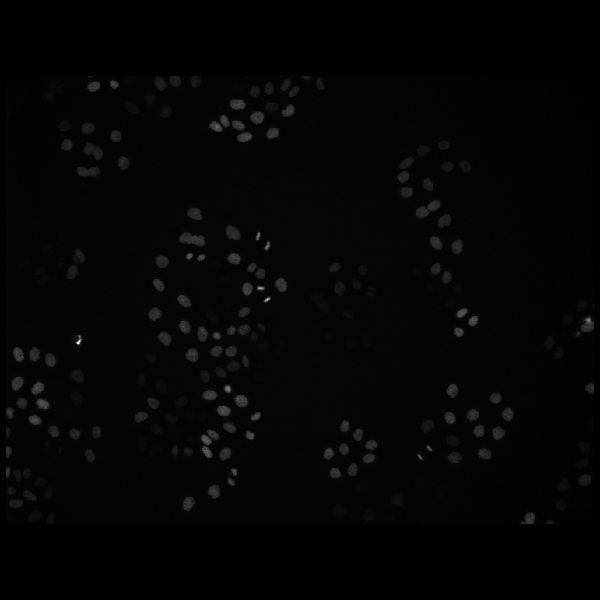

In [5]:
viewer.widget().children[1].snapshot()

In [6]:
# Flatten image and get the mode
mode_val = scipy.stats.mode(image.ravel(), keepdims=False).mode
print(f"Estimated background (mode): {mode_val:.3f}")

Estimated background (mode): 33055.000


In [7]:
# Subtract mode from the image (after converting to float32)
image_mode_sub = image.astype(np.float32) - mode_val
print(f"Min: {image_mode_sub.min():.2f}, Max: {image_mode_sub.max():.2f}")

Min: -71.00, Max: 3808.00


In [8]:
image_mode_sub_to_zero = np.clip(image_mode_sub, 0, None)
print(
    f"Min: {image_mode_sub_to_zero.min():.2f}, Max: {image_mode_sub_to_zero.max():.2f}"
)

Min: 0.00, Max: 3808.00


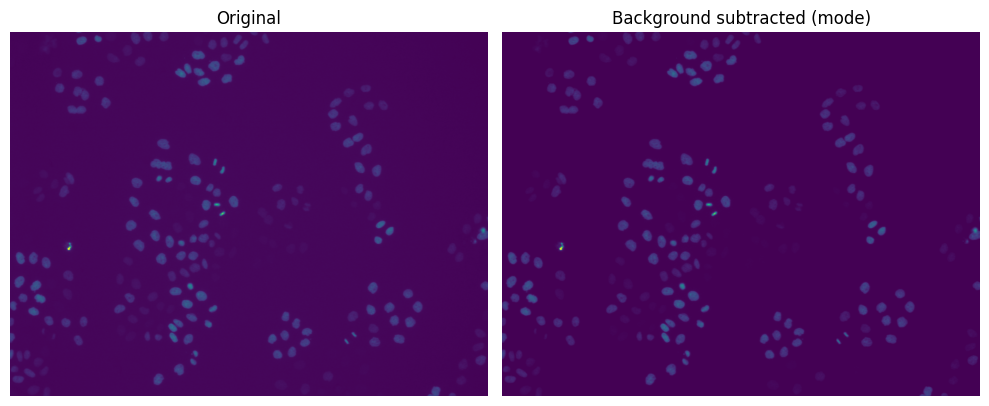

In [9]:
plt.figure(figsize=(10, 8))
plt.subplot(121)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(image_mode_sub_to_zero)
plt.title("Background subtracted (mode)")
plt.axis("off")

plt.tight_layout()
plt.show()

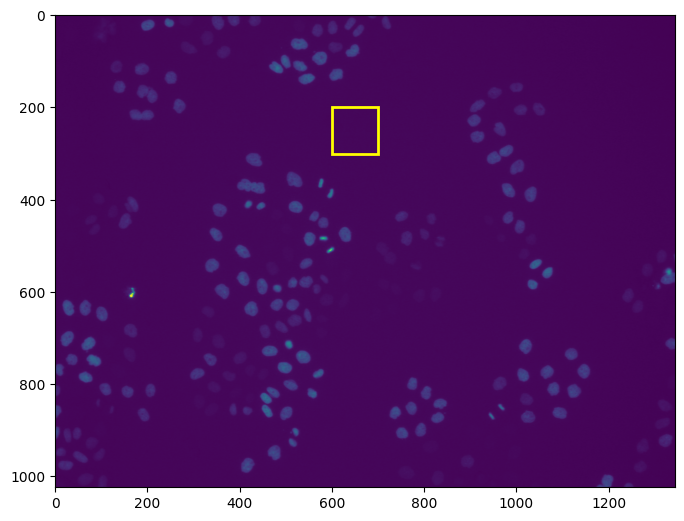

In [10]:
# plot the image with axis turned on to select a region
plt.figure(figsize=(8, 8))
plt.imshow(image)
# draw a rectangle around the region we want to select
x = 600
y = 200
width = 100
height = 100
plt.gca().add_patch(
    plt.Rectangle(
        (x, y),  # top-left corner
        width,  # width
        height,  # height
        edgecolor="yellow",
        facecolor="none",
        linewidth=2,
    )
)
plt.show()

In [11]:
# Choose a top-left corner patch assumed to be background
# The region selected above is (600, 200) with size 100x100 therefore we can extract the
# patch as follows: [y:y+height, x:x+width]
bg_patch = image[y : y + height, x : x + width]  # image[200:300, 600:700]
bg_mean = np.mean(bg_patch)
print(f"Estimated background (mean of selected region): {bg_mean:.3f}")

Estimated background (mean of selected region): 33055.170


In [12]:
image_mean_sub = image.astype(np.float32) - mode_val
print(f"Min: {image_mean_sub.min():.2f}, Max: {image_mean_sub.max():.2f}")
image_mean_sub_to_zero = np.clip(image_mean_sub, 0, None)
print(
    f"Min: {image_mean_sub_to_zero.min():.2f}, Max: {image_mean_sub_to_zero.max():.2f}"
)

Min: -71.00, Max: 3808.00
Min: 0.00, Max: 3808.00


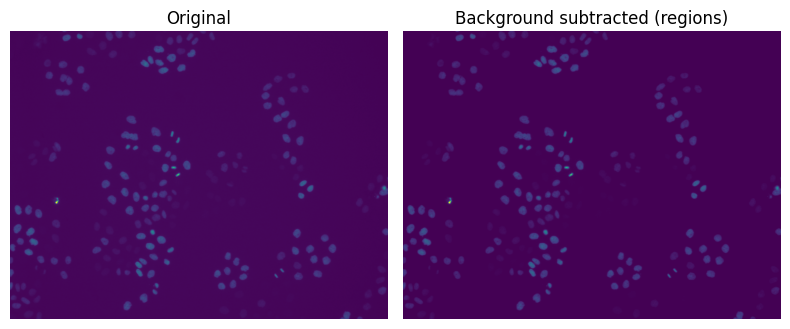

In [13]:
plt.figure(figsize=(8, 8))
plt.subplot(121)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(image_mean_sub_to_zero)
plt.title("Background subtracted (regions)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# raw image
image = tifffile.imread("../../_static/images/quant/07_bg_corr_WF_drosophila.tif")

In [ ]:
ndv.imshow(image)

In [15]:
viewer = ndv.imshow(image)

RFBOutputContext()

<IPython.core.display.Javascript object>


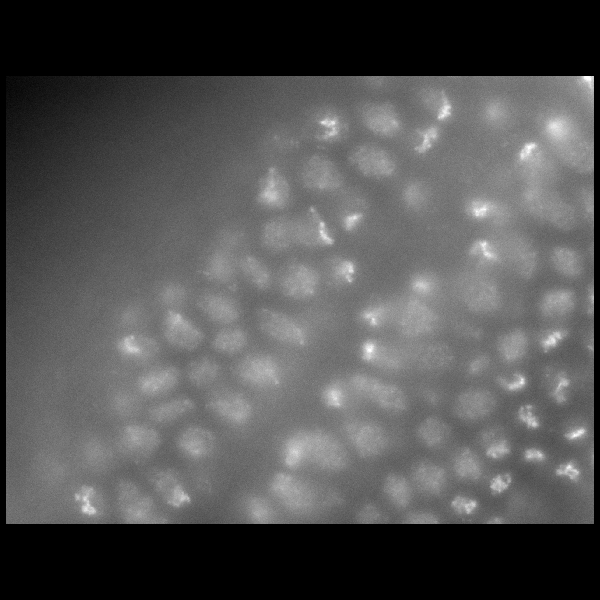

In [16]:
viewer.widget().children[1].snapshot()

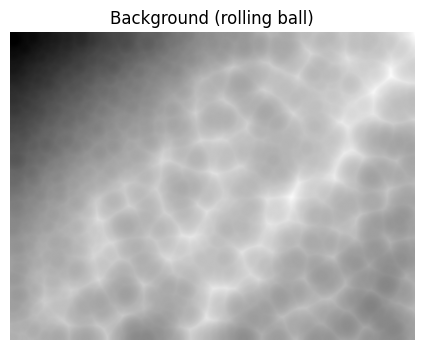

In [17]:
background_residue = skimage.restoration.rolling_ball(image, radius=100)

plt.figure(figsize=(8, 4))
plt.imshow(background_residue, cmap="gray")
plt.title("Background (rolling ball)")
plt.axis("off")
plt.show()

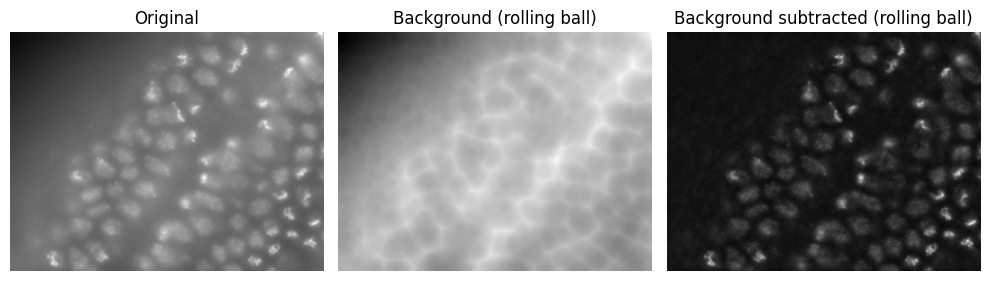

In [18]:
image_rb_sub = image - background_residue

plt.figure(figsize=(10, 10))

plt.subplot(131)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(background_residue, cmap="gray")
plt.title("Background (rolling ball)")
plt.axis("off")

plt.subplot(133)
plt.imshow(image_rb_sub, cmap="gray")
plt.title("Background subtracted (rolling ball)")
plt.axis("off")

plt.tight_layout()
plt.show()